# Deep Learning Experiment: Image Classification on Fashion-MNIST

**Author:** Sébastien Bodrero
**Programme:** MSc in Artificial Intelligence — Woolf University / Udacity
**Module 4:** Deep Learning Systems
**Date:** April 2026

---

This notebook implements a deep learning experiment workflow for image classification using the **Fashion-MNIST** dataset (70,000 grayscale 28×28 images, 10 clothing categories). A **Convolutional Neural Network (CNN)** is the natural choice for this task: CNNs exploit spatial structure through local receptive fields and weight sharing, making them highly parameter-efficient for image data compared to fully connected networks (LeCun et al., 1998).

The experiment compares two configurations:
- **Baseline SimpleCNN** — two convolutional blocks + two fully connected layers, no regularization
- **CNN + Dropout** — identical architecture with `Dropout(p=0.5)` applied after the first fully connected layer

The notebook follows six structured sections:

1. **Setup** — imports and device configuration
2. **Dataset & Preprocessing** — data loading, normalization, visualization
3. **Baseline Model** — SimpleCNN architecture, training, loss curve
4. **Experimental Model** — CNN + Dropout, training, loss curve
5. **Evaluation & Comparison** — test accuracy, confusion matrix, example predictions
6. **Notebook Summary** — findings and limitations

## 1. Setup

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration — runs on CPU if no GPU available
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print(f'PyTorch      {torch.__version__}')
print(f'torchvision  {torchvision.__version__}')
print(f'NumPy        {np.__version__}')
print(f'Matplotlib   {matplotlib.__version__}')
print(f'Device       {DEVICE}')

PyTorch      2.11.0
torchvision  0.26.0
NumPy        2.4.4
Matplotlib   3.10.8
Device       cpu


## 2. Dataset & Preprocessing

**Fashion-MNIST** (Xiao et al., 2017) is a drop-in replacement for MNIST containing 70,000 grayscale 28×28 images of clothing items across 10 classes. It is distributed by Zalando Research and is publicly available via `torchvision.datasets`. The dataset is downloaded automatically on first run into a local `data/` directory.

| Split | Samples |
|-------|---------|
| Training | 60,000 |
| Test | 10,000 |

**Preprocessing:** Images are converted to tensors and normalized using the dataset's population statistics (mean = 0.2860, std = 0.3530). Normalization is standard practice for neural network training: it centers the input distribution, accelerates gradient-based optimization, and reduces sensitivity to initial weight scale.

In [3]:
CLASS_NAMES = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# Normalization constants computed from the FashionMNIST training set
FMNIST_MEAN = (0.2860,)
FMNIST_STD  = (0.3530,)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(FMNIST_MEAN, FMNIST_STD)
])

train_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform
)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Training samples : {len(train_dataset):,}')
print(f'Test samples     : {len(test_dataset):,}')
print(f'Batch size       : {BATCH_SIZE}')
print(f'Training batches : {len(train_loader)}')
print(f'Classes          : {CLASS_NAMES}')

100.0%
100.0%
100.0%
100.0%


Training samples : 60,000
Test samples     : 10,000
Batch size       : 64
Training batches : 938
Classes          : ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


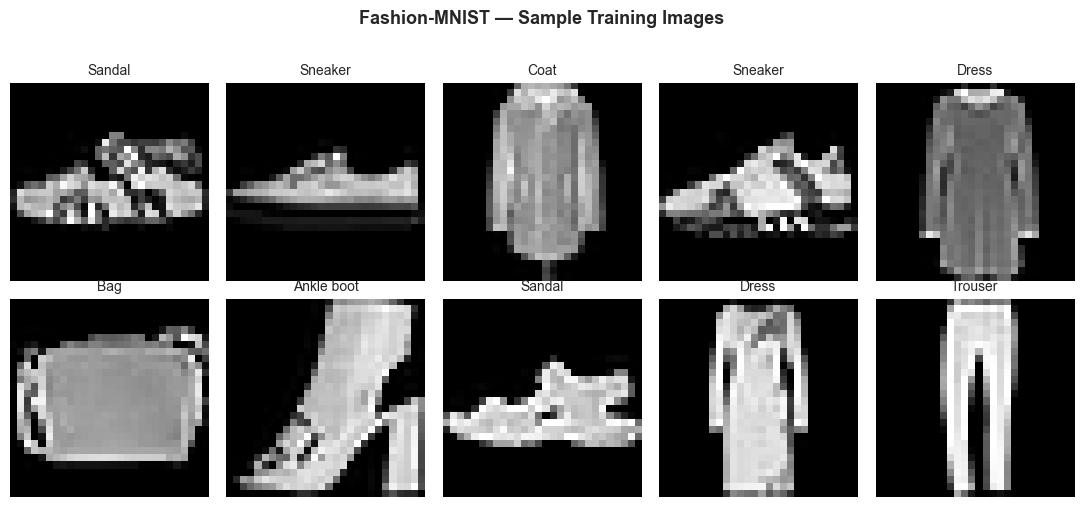

In [4]:
# Display 10 sample images from the training set
images, labels = next(iter(train_loader))

# Denormalize for display
def denorm(img_tensor):
    """Reverse normalization for display purposes."""
    return img_tensor * FMNIST_STD[0] + FMNIST_MEAN[0]

fig, axes = plt.subplots(2, 5, figsize=(11, 5))
for i, ax in enumerate(axes.flat):
    img = denorm(images[i].squeeze())
    ax.imshow(img.numpy(), cmap='gray')
    ax.set_title(CLASS_NAMES[labels[i].item()], fontsize=10)
    ax.axis('off')

fig.suptitle('Fashion-MNIST — Sample Training Images', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()